# Notebook 1 — Diversidad alfa taxonómica

Calcula índices de diversidad alfa a partir de `all_samples.tsv`, une los resultados con `metadata_cibimi.csv` y guarda las gráficas en `plots/`.

In [6]:
# Instalación de dependencias (ejecutar si es necesario)
# En Google Colab o un ambiente limpio, descomenta la siguiente línea:
!pip install pandas numpy scipy scikit-bio seaborn matplotlib statsmodels openpyxl xlrd scikit-learn

import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")

PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

ALL_SAMPLES_URL = "https://raw.githubusercontent.com/shadayguerrero/neonatal-gut-microbiome-analysis/refs/heads/main/data/all_samples.tsv"
METADATA_URL = "https://raw.githubusercontent.com/shadayguerrero/neonatal-gut-microbiome-analysis/refs/heads/main/data/metadata_cibimi.csv"
FUNCTION_URL = "https://raw.githubusercontent.com/shadayguerrero/neonatal-gut-microbiome-analysis/refs/heads/main/data/output_all_levels_and_function.csv"

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

def save_current_fig(filename, dpi=300):
    """Guarda la figura actual dentro de plots/ y la muestra."""
    path = PLOTS_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Figura guardada en: {path}")
    plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 74.3 MB/s eta 0:00:00


In [7]:
 #!pip install pandas numpy scipy scikit-bio seaborn matplotlib statsmodels openpyxl xlrd scikit-learn

## 1. Carga y preparación de datos

In [8]:
def load_metadata(url=METADATA_URL):
    metadata = pd.read_csv(url)
    metadata = metadata.rename(columns={"MBI Sample ID": "SampleID"})
    metadata["SampleID"] = metadata["SampleID"].astype(str).str.strip()
    metadata = metadata.set_index("SampleID")
    if "Week" in metadata.columns:
        metadata["Week"] = pd.to_numeric(metadata["Week"], errors="coerce")
    if "Baby number" in metadata.columns:
        metadata["Baby number"] = metadata["Baby number"].astype(str)
    return metadata

def clean_sample_id(sample_name):
    return str(sample_name).split("_")[0].strip()

def load_otu_table(url=ALL_SAMPLES_URL):
    # El archivo all_samples.tsv incluye una primera línea extra en algunos exports de biom.
    otu = pd.read_csv(url, sep="\t", skiprows=1)
    otu = otu.rename(columns={"#OTU ID": "OTU_ID"})
    if "OTU_ID" not in otu.columns:
        otu = pd.read_csv(url, sep="\t")
        otu = otu.rename(columns={"#OTU ID": "OTU_ID"})
    if "Consensus Lineage" not in otu.columns:
        raise ValueError("No se encontró la columna 'Consensus Lineage' en all_samples.tsv")
    otu = otu.set_index("OTU_ID")
    sample_cols = [c for c in otu.columns if c != "Consensus Lineage"]
    counts = otu[sample_cols].apply(pd.to_numeric, errors="coerce").fillna(0).T
    counts.index = [clean_sample_id(i) for i in counts.index]
    counts = counts.groupby(counts.index).sum()
    taxonomy = otu["Consensus Lineage"].copy()
    return counts, taxonomy, otu

def align_counts_metadata(counts, metadata):
    common = counts.index.intersection(metadata.index)
    counts_aligned = counts.loc[common].copy()
    metadata_aligned = metadata.loc[common].copy()
    print(f"Muestras usadas: {counts_aligned.shape[0]}")
    print(f"Features/ASVs: {counts_aligned.shape[1]}")
    return counts_aligned, metadata_aligned

metadata = load_metadata()
otu_counts, taxonomy, otu_raw = load_otu_table()
otu_counts, metadata = align_counts_metadata(otu_counts, metadata)
metadata.head()

Muestras usadas: 83
Features/ASVs: 10794


,Your Sample ID,Baby number,Sampling Date,Weeks of gestation,Sample Type,Group,Sex,Weight,Size,Head Circunference,Abdominal Circunference,Necrotizing enterocolitis,Type of Birth,Clasification birth weight,Week
S00SO-0001,C3.1,3,Week 1 (Birth),27.0,human feces,CONTROL,fem,800.0,34.0,24.0,18.0,No presence,Cesarean,Extremely low,1
S00SO-0002,C3.2,3,Week 2,NaN,human feces,CONTROL,fem,805.0,34.0,23.0,18.0,No presence,Cesarean,Extremely low,2
S00SO-0003,C3.3,3,Week 3,NaN,human feces,CONTROL,fem,870.0,34.0,24.0,20.0,No presence,Cesarean,Extremely low,3
S00SO-0004,C3.4,3,Week 4,NaN,human feces,CONTROL,fem,910.0,34.0,24.0,20.0,No presence,Cesarean,Extremely low,4
S00SO-0005,C3.5,3,Week 5,NaN,human feces,CONTROL,fem,NaN,NaN,NaN,NaN,No presence,Cesarean,Extremely low,5


## 2. Cálculo de diversidad alfa

In [9]:
from skbio.diversity import alpha_diversity

alpha_metrics = {
    "shannon": "Shannon",
    "simpson": "Simpson",
    "observed_otus": "Riqueza observada"
}

alpha_df = pd.DataFrame(index=otu_counts.index)
for metric in alpha_metrics:
    alpha_df[metric] = alpha_diversity(metric=metric, counts=otu_counts.values, ids=otu_counts.index)

alpha_df = alpha_df.join(metadata)
alpha_df.to_csv("alpha_diversity_results.csv")
alpha_df.head()

/usr/local/lib/python3.12/dist-packages/skbio/util/_warning.py:42: DeprecationWarning: `observed_otus` was renamed to `sobs` in 0.6.0. The old name is kept as an alias but is deprecated.
  warn(message, warning)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,shannon,simpson,observed_otus,Your Sample ID,Baby number,Sampling Date,Weeks of gestation,Sample Type,Group,Sex,Weight,Size,Head Circunference,Abdominal Circunference,Necrotizing enterocolitis,Type of Birth,Clasification birth weight,Week
S00SO-0001,3.208625,0.803503,394,C3.1,3,Week 1 (Birth),27.0,human feces,CONTROL,fem,800.0,34.0,24.0,18.0,No presence,Cesarean,Extremely low,1
S00SO-0002,0.952912,0.301147,665,C3.2,3,Week 2,NaN,human feces,CONTROL,fem,805.0,34.0,23.0,18.0,No presence,Cesarean,Extremely low,2
S00SO-0003,0.877723,0.335391,885,C3.3,3,Week 3,NaN,human feces,CONTROL,fem,870.0,34.0,24.0,20.0,No presence,Cesarean,Extremely low,3
S00SO-0004,0.826832,0.311557,924,C3.4,3,Week 4,NaN,human feces,CONTROL,fem,910.0,34.0,24.0,20.0,No presence,Cesarean,Extremely low,4
S00SO-0005,1.234499,0.474198,1097,C3.5,3,Week 5,NaN,human feces,CONTROL,fem,NaN,NaN,NaN,NaN,No presence,Cesarean,Extremely low,5


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 3. Gráficas por grupo

Figura guardada en: plots/alpha_shannon_por_Group.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


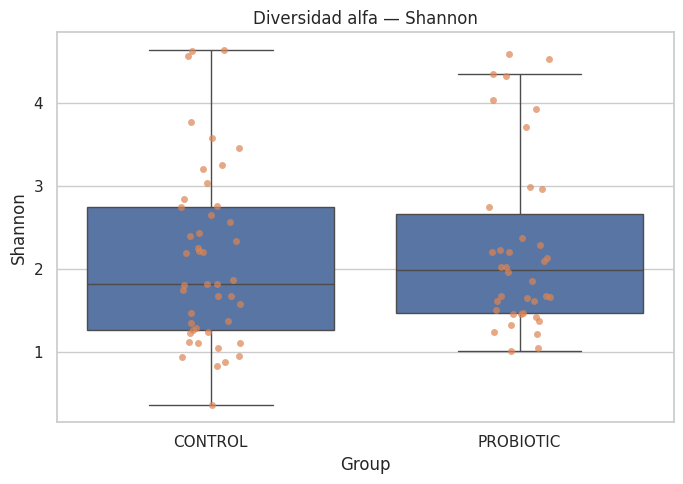

Figura guardada en: plots/alpha_simpson_por_Group.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


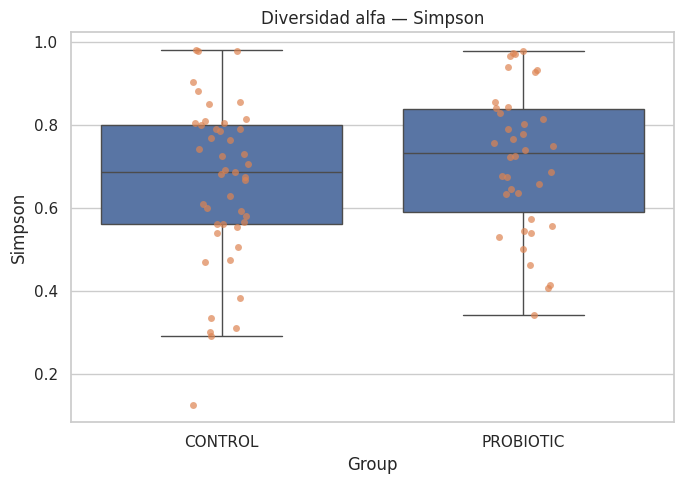

Figura guardada en: plots/alpha_observed_otus_por_Group.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


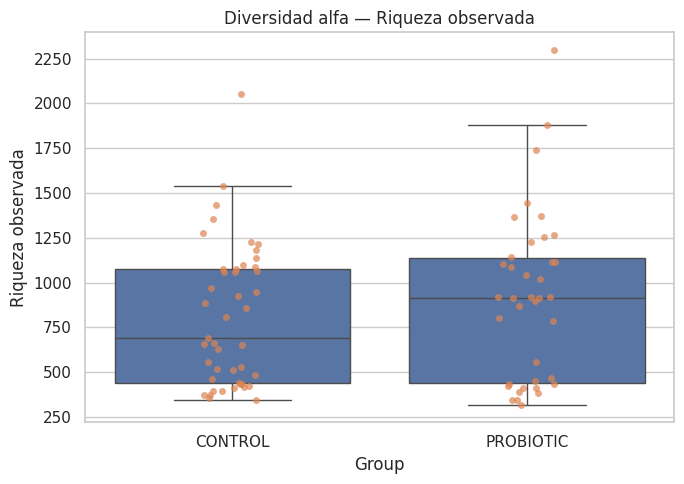

In [10]:
group_col = "Group"

for metric, label in alpha_metrics.items():
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=alpha_df, x=group_col, y=metric, showfliers=False)
    sns.stripplot(data=alpha_df, x=group_col, y=metric, jitter=True, alpha=0.7)
    plt.title(f"Diversidad alfa — {label}")
    plt.xlabel(group_col)
    plt.ylabel(label)
    save_current_fig(f"alpha_{metric}_por_{group_col}.png")

## 4. Evolución por semana

Figura guardada en: plots/alpha_shannon_por_semana.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


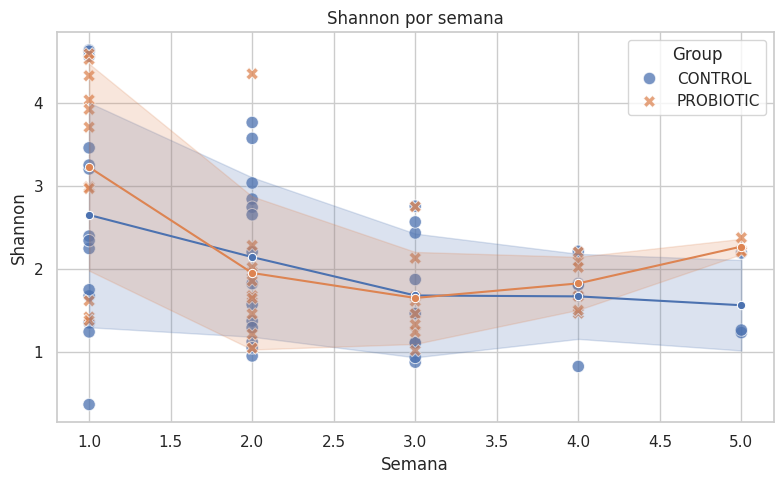

Figura guardada en: plots/alpha_simpson_por_semana.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


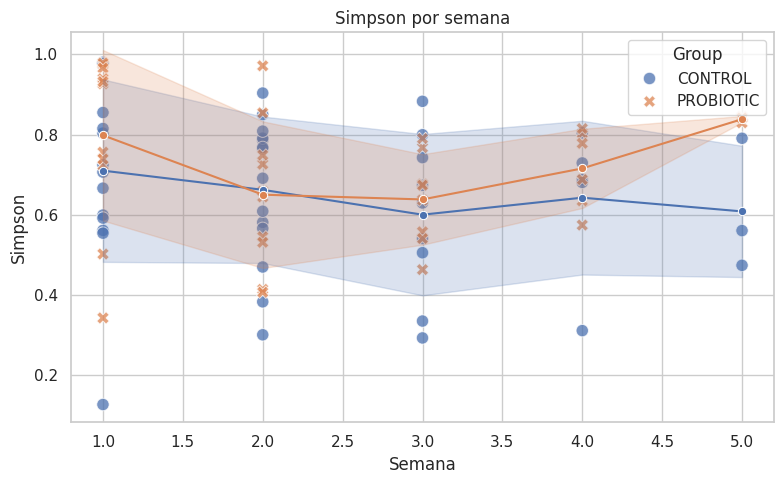

Figura guardada en: plots/alpha_observed_otus_por_semana.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


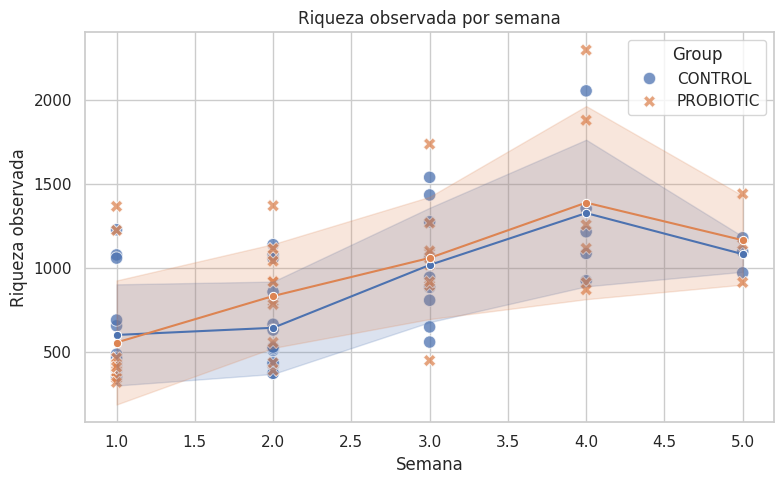

In [11]:
if "Week" in alpha_df.columns:
    for metric, label in alpha_metrics.items():
        plt.figure(figsize=(8, 5))
        sns.scatterplot(data=alpha_df, x="Week", y=metric, hue="Group", style="Group", s=80, alpha=0.75)
        sns.lineplot(data=alpha_df, x="Week", y=metric, hue="Group", estimator="mean", errorbar="sd", marker="o", legend=False)
        plt.title(f"{label} por semana")
        plt.xlabel("Semana")
        plt.ylabel(label)
        save_current_fig(f"alpha_{metric}_por_semana.png")
else:
    print("No se encontró la columna Week en los metadatos.")

## 5. Modelo mixto opcional

Evalúa el efecto de `Week`, `Group` y su interacción, controlando medidas repetidas por bebé.

In [12]:
import statsmodels.formula.api as smf

required_cols = {"Week", "Group", "Baby number"}
if required_cols.issubset(alpha_df.columns):
    model_results = {}
    for metric in alpha_metrics:
        data_model = alpha_df[[metric, "Week", "Group", "Baby number"]].dropna()

        # Filter out 'Baby number' groups with only one observation
        group_counts = data_model.groupby("Baby number").size()
        valid_babies = group_counts[group_counts > 1].index
        data_model_filtered = data_model[data_model["Baby number"].isin(valid_babies)]

        if not data_model_filtered.empty and data_model_filtered["Baby number"].nunique() > 1:
            print(f"\nFitting mixed model for {metric} with {data_model_filtered['Baby number'].nunique()} valid babies and {len(data_model_filtered)} observations...")
            try:
                model = smf.mixedlm(f"{metric} ~ Week * Group", data=data_model_filtered, groups=data_model_filtered["Baby number"])
                result = model.fit(reml=False, method="lbfgs", maxiter=1000) # Increased maxiter for robustness
                model_results[metric] = result
                print(f"\n===== {metric} ====")
                print(result.summary())
            except Exception as e:
                print(f"Error fitting mixed model for {metric}: {e}")
                print("This might be due to insufficient variance within groups or other convergence issues.")
        else:
            print(f"Skipping mixed model for {metric}: Not enough valid 'Baby number' groups (each with >1 observation) after filtering out NaNs.")
else:
    print(f"Faltan columnas para el modelo mixto: {required_cols - set(alpha_df.columns)}")


Fitting mixed model for shannon with 25 valid babies and 81 observations...
Error fitting mixed model for shannon: Singular matrix
This might be due to insufficient variance within groups or other convergence issues.

Fitting mixed model for simpson with 25 valid babies and 81 observations...
Error fitting mixed model for simpson: Singular matrix
This might be due to insufficient variance within groups or other convergence issues.

Fitting mixed model for observed_otus with 25 valid babies and 81 observations...
Error fitting mixed model for observed_otus: Singular matrix
This might be due to insufficient variance within groups or other convergence issues.


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
